# NYC：总体表现与 recourse 对比（两张图）

读取 `results/nye_results` 中六份原始 Excel，不修改工作簿。从上到下运行即可在 `results/nye_results/paper_figures/` 生成两张 PNG 和两张 PDF。

图 1 比较 Myopic r1/r2、Learning r1/r2/r3、Macro；保留 reward、完成量、服务率，第四个面板改成全网平均队列柱状图。图 2 比较全部六种方法的日均 recourse 数量及 recourse/(recourse+lost) 比值。数据表保存到 `results/nye_results/analysis/`。

In [1]:
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'results/nye_results').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('请从 icaps 项目或其子目录运行 notebook。')
DATA_DIR = ROOT / 'results/nye_results'
FIG_DIR = DATA_DIR / 'paper_figures'
ANALYSIS_DIR = DATA_DIR / 'analysis'
FIG_DIR.mkdir(exist_ok=True)
ANALYSIS_DIR.mkdir(exist_ok=True)
EPOCH_SECONDS = 30.0  # 与这些导出结果的 NYC 测试设置一致
SPECS = [
    ('benchmark_r1', 'Myopic r1', 'MCMF', 'r1', '#697786'),
    ('benchmark_r2', 'Myopic r2', 'MCMF', 'r2', '#b28c57'),
    ('r1', 'Learning r1', 'ADP-MCMF', 'r1', '#4c78a8'),
    ('r2', 'Learning r2', 'ADP-MCMF', 'r2', '#9b6cb3'),
    ('r3', 'Learning r3', 'ADP-MCMF', 'r3', '#e48144'),
    ('macro', 'Macro', 'ADP-MCMF', 'macro', '#219b89'),
]
ORDER = [s[1] for s in SPECS]
COLORS = {s[1]: s[4] for s in SPECS}
STYLE = {label: '--' if label.startswith('Myopic') else '-' for label in ORDER}
mpl.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11, 'axes.titlesize': 13,
    'axes.labelsize': 11, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': .18, 'axes.axisbelow': True,
    'figure.dpi': 110, 'savefig.dpi': 240, 'pdf.fonttype': 42,
})
FIGURES = []

def save_show(fig, name, description):
    for suffix in ['png', 'pdf']:
        fig.savefig(FIG_DIR / f'{name}.{suffix}', bbox_inches='tight', facecolor='white')
    FIGURES.append({'name': name, 'description': description})
    plt.show()
    plt.close(fig)

def line(ax, label, x, y, **kwargs):
    ax.plot(x, y, color=COLORS[label], linestyle=STYLE[label],
            linewidth=2.1, label=label, **kwargs)

def bars(ax, values, title, ylabel, fmt='.1f'):
    values = np.asarray(values, dtype=float)
    rects = ax.bar(np.arange(len(ORDER)), values, color=[COLORS[s] for s in ORDER], width=.7)
    for label, rect in zip(ORDER, rects):
        if label.startswith('Myopic'):
            rect.set_hatch('//')
            rect.set_edgecolor('white')
    ax.bar_label(rects, labels=[format(v, fmt) if np.isfinite(v) else 'n/a' for v in values],
                 padding=4, fontsize=9)
    ax.set_xticks(range(len(ORDER)), [x.replace(' ', '\n', 1) for x in ORDER])
    ax.set(title=title, ylabel=ylabel)
    ax.set_ylim(0, max(float(np.nanmax(values)) * 1.19, 1))
    ax.grid(axis='x', visible=False)

## 口径

当前为同一种子 256、2025-12-15 至 2025-12-17 三天结果。没有多种子误差带。

- reward 与 EV/AEV 完成量已经是日均；`complete`、`recourse_requests`、`lost_requests` 为三天合计，除以 3 后作图。图中分别使用百万美元/日或千单/日，数据表保留美元/日和单/日。
- 服务率 = 三天完成总量 / 三天需求总量。它与逐日服务率的等权平均略有区别。
- **平均队列是全网队列总长度的时间均值，不是每站平均，也不是分布直方图。** 先对同小时的全部站点求和，再对 72 个小时均值取平均：

\[
\bar Q_m=\frac{1}{3\times24}\sum_{d=1}^{3}\sum_{h=0}^{23}\sum_z\bar Q_{m,d,h,z}.
\]

`mean_queue_vehicle_count` 包括 **实际排队车辆 + 尚未到达的预约车辆**（`charging_queue + charging_queue_notarrived`），混合导出的站点/车辆类型。当前为 428 个站点，不能解释为 3 个 AEV 换电中心的纯到站队列。原表无法分离这两类车辆，图中因此明确标为 **waiting + inbound**。每站平均另存数据列，不作为主图。

- recourse = EV 拒绝后同一决策轮重新指派给 AEV 的订单数，不等于最终完成的 recourse 订单。EV/AEV 完成量和收益是该类型的全部贡献，不能全部归因于拒单补救。
- 第二张图的 recourse/(recourse+lost) 是描述性计数比值，不是同一订单群体的补救成功率。lost 包含未被拒过的订单；再指派订单也可能最终流失，因此两项不构成互斥、穷尽的结果分类。

In [2]:
SHEETS = ['detail', 'daily_req_completion_summary', 'hourly_req_completion_summary',
          'hourly_completed_summary', 'hourly_station_queue_summary', 'hourly_zone_vehicle_summary']
books, source_info = {}, []
for suffix, label, strategy, method, color in SPECS:
    path = DATA_DIR / f'test_results_4way_optimization_anchored_residual_{suffix}.xlsx'
    book = pd.read_excel(path, sheet_name=SHEETS)
    for sheet, frame in book.items():
        assert set(frame['strategy']) == {strategy}, (label, sheet, 'strategy mismatch')
        assert set(frame['method']) == {method}, (label, sheet, 'method mismatch')
        for col in ['date', 'request_date', 'completed_date']:
            if col in frame:
                frame[col] = pd.to_datetime(frame[col]).dt.normalize()
    # 当前文件只含一个种子。以后合并多种子时应显式新增种子层级，不能静默当日平均。
    assert len(book['detail']) == 1, f'{label}: 请为多种子结果增加种子层级聚合。'
    books[label] = book
    source_info.append({'label': label, 'file': path.name,
                        'sha256': hashlib.sha256(path.read_bytes()).hexdigest()})

raw = pd.concat([b['detail'].assign(label=label) for label, b in books.items()], ignore_index=True).set_index('label').loc[ORDER]
assert raw['seed'].nunique() == 1, '比较必须使用相同种子。'
assert raw['episodes'].nunique() == 1
N_DAYS = int(raw['episodes'].iloc[0])
SEED = int(raw['seed'].iloc[0])
DATES = sorted(books[ORDER[0]]['daily_req_completion_summary']['request_date'].unique())
assert len(DATES) == N_DAYS
PERIOD = f'{pd.Timestamp(DATES[0]):%Y-%m-%d} to {pd.Timestamp(DATES[-1]):%Y-%m-%d}; seed {SEED}'
ref_demand = None
validation_rows = []
for label, book in books.items():
    d = book['daily_req_completion_summary']
    h = book['hourly_completed_summary']
    q = book['hourly_req_completion_summary']
    assert not d.duplicated(['request_date', 'zone_id']).any()
    assert not h.duplicated(['completed_date', 'completed_hour']).any()
    assert not q.duplicated(['request_date', 'request_hour', 'zone_id']).any()
    assert sorted(d.request_date.unique()) == DATES
    demand = q.set_index(['request_date', 'request_hour', 'zone_id']).generated_requests.sort_index()
    if ref_demand is None:
        ref_demand = demand
    else:
        idx = ref_demand.index.union(demand.index)
        np.testing.assert_allclose(ref_demand.reindex(idx, fill_value=0), demand.reindex(idx, fill_value=0))
    r = raw.loc[label]
    np.testing.assert_allclose(d.generated_requests.sum(), r.total_orders)
    np.testing.assert_allclose(q.generated_requests.sum(), r.total_orders)
    np.testing.assert_allclose(d.completed_requests.sum(), r.complete)
    np.testing.assert_allclose(q.completed_requests.sum(), r.complete)
    np.testing.assert_allclose(h.mean_completed_orders.sum(), r.complete)
    np.testing.assert_allclose(h.mean_completed_ev_orders + h.mean_completed_aev_orders, h.mean_completed_orders)
    np.testing.assert_allclose(r.avg_reward * N_DAYS, r.total_reward)
    np.testing.assert_allclose(r.episode_reward_ev + r.episode_reward_aev, r.avg_reward)
    np.testing.assert_allclose((r.mean_ev_completed_orders + r.mean_aev_completed_orders) * N_DAYS, r.complete)
    validation_rows.append({'Method': label, 'Seed': SEED, 'Days': N_DAYS,
                            'Demand total': int(r.total_orders), 'Completed total': int(r.complete)})
display(pd.DataFrame(validation_rows))
print('Validated: same hourly/zone demand, same seed/dates, reward and completion totals reconcile.')
# 保留原 notebook 的便捷变量名。
data_benchmark_r1, data_benchmark_r2, data_r1, data_r2, data_r3, data_macro = [books[k]['detail'] for k in ORDER]

Validated: same hourly/zone demand, same seed/dates, reward and completion totals reconcile.


,Method,Seed,Days,Demand total,Completed total
0,Myopic r1,256,3,358212,282334
1,Myopic r2,256,3,358212,327808
2,Learning r1,256,3,358212,275164
3,Learning r2,256,3,358212,327576
4,Learning r3,256,3,358212,276350
5,Macro,256,3,358212,301080


In [3]:
metrics = pd.DataFrame(index=ORDER)
metrics.index.name = 'Method'
metrics['reward_per_day'] = raw.avg_reward
metrics['completed_per_day'] = raw.complete / N_DAYS
metrics['service_pooled_pct'] = 100 * raw.complete / raw.total_orders
metrics['service_daily_mean_pct'] = 100 * raw.mean_service_ratio
metrics['charging_wait_positive_records_min'] = raw.avg_wait * EPOCH_SECONDS / 60
metrics['waiting_records_per_day'] = raw.waiting_vehicle_count / N_DAYS
metrics['completed_charges_per_day'] = raw.finished_charge
metrics['mean_daily_final_soc_pct'] = raw.avg_battery_level * 100
metrics['recourse_per_day'] = raw.recourse_requests / N_DAYS
metrics['lost_requests_per_day'] = raw.lost_requests / N_DAYS
metrics['rejected_unique_per_day'] = raw.rejected_requests / N_DAYS

# 先逐小时对站点（按 zone 导出）求和，再对三个完整日的 72 个小时求均值。
# mean_queue_vehicle_count 包括 charging_queue_notarrived，不是纯到站等待人数。
queue_hourly = {}
for label, book in books.items():
    s = book['hourly_station_queue_summary']
    assert not s.duplicated(['date', 'hour', 'zone_id']).any()
    hourly_queue = s.groupby(['date', 'hour'])[['mean_queue_vehicle_count', 'mean_station_count']].sum()
    expected = pd.MultiIndex.from_product([DATES, range(24)], names=['date', 'hour'])
    assert hourly_queue.index.equals(expected), f'{label}: 队列小时数据不完整'
    queue_hourly[label] = hourly_queue
    metrics.loc[label, 'mean_network_queue_including_inbound'] = hourly_queue.mean_queue_vehicle_count.mean()
    metrics.loc[label, 'mean_queue_per_exported_station'] = (hourly_queue.mean_queue_vehicle_count / hourly_queue.mean_station_count).mean()
    metrics.loc[label, 'exported_station_count'] = hourly_queue.mean_station_count.iloc[0]
    assert hourly_queue.mean_station_count.nunique() == 1
display(metrics[['reward_per_day', 'completed_per_day', 'service_pooled_pct',
                 'mean_network_queue_including_inbound', 'exported_station_count']].round(2))
metrics.to_csv(ANALYSIS_DIR / 'comparison_metrics.csv')
pd.concat(queue_hourly, names=['Method']).to_csv(ANALYSIS_DIR / 'network_queue_hourly.csv')


,reward_per_day,completed_per_day,service_pooled_pct,mean_network_queue_including_inbound,exported_station_count
Method,,,,,
Myopic r1,1933457.04,94111.33,78.82,15.28,428.0
Myopic r2,2088286.60,109269.33,91.51,70.67,428.0
Learning r1,2636271.02,91721.33,76.82,217.13,428.0
Learning r2,2163098.64,109192.00,91.45,54.28,428.0
Learning r3,2564781.48,92116.67,77.15,287.34,428.0
Macro,2674561.90,100360.00,84.05,159.00,428.0


## 图 1：总体表现

第四个面板越低表示全网“等待＋在途预约”平均数量越少；不据此判断纯到站等待或严格预约是否无排队。

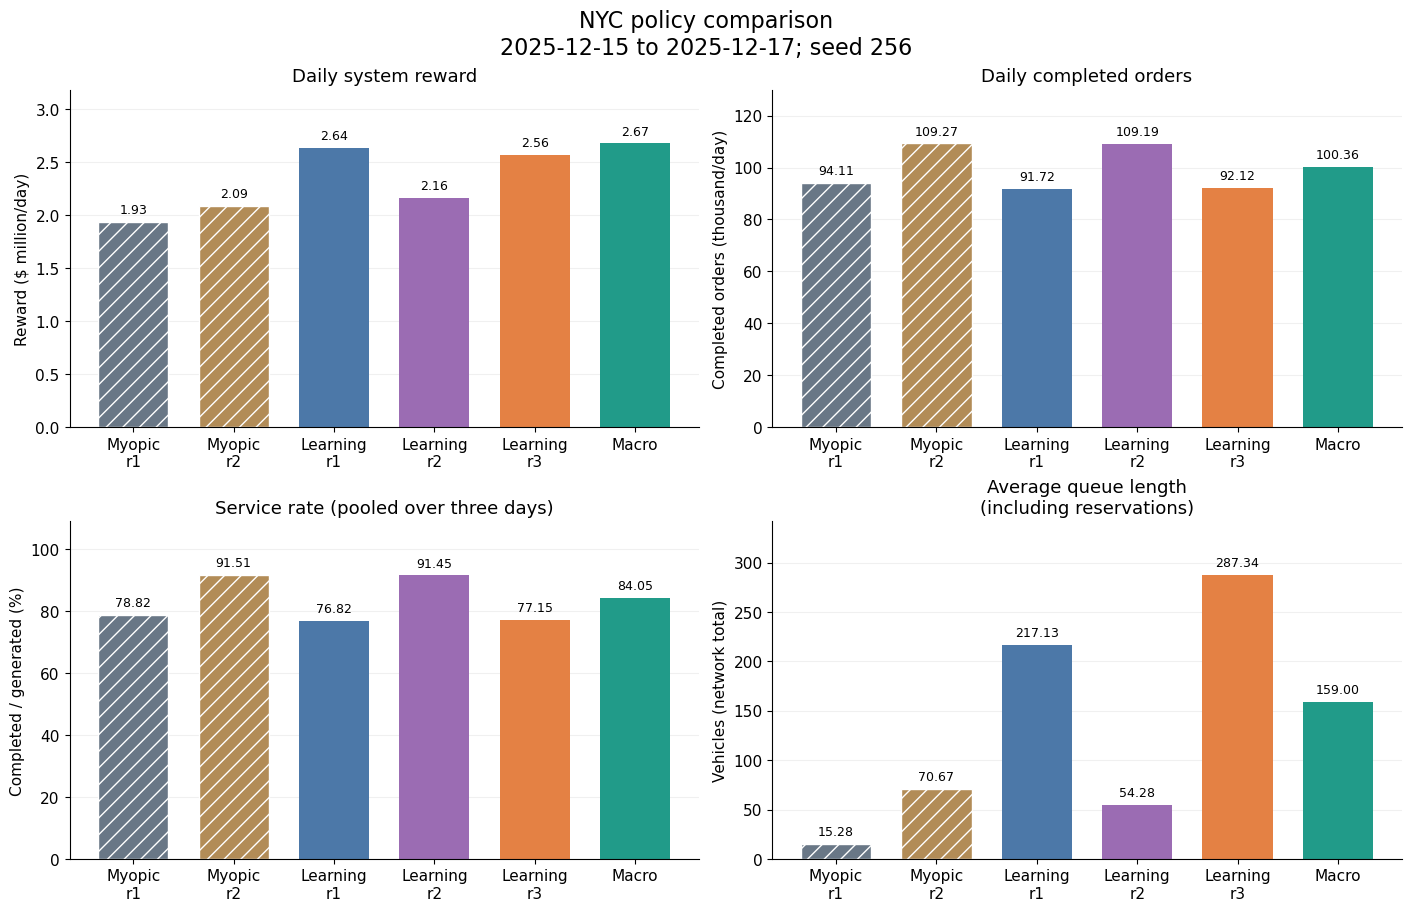

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), layout='constrained')
bars(axes[0, 0], metrics.reward_per_day / 1e6, 'Daily system reward', 'Reward ($ million/day)', '.2f')
bars(axes[0, 1], metrics.completed_per_day / 1000, 'Daily completed orders', 'Completed orders (thousand/day)', '.2f')
bars(axes[1, 0], metrics.service_pooled_pct, 'Service rate (pooled over three days)', 'Completed / generated (%)', '.2f')
bars(axes[1, 1], metrics.mean_network_queue_including_inbound, 'Average queue length\n(including reservations)', 'Vehicles (network total)', '.2f')
fig.suptitle('NYC policy comparison\n' + PERIOD, fontsize=16)
save_show(fig, '01_policy_overview', 'Daily reward/completions, pooled service rate, mean network queue including inbound reservations')

## 图 2：Recourse 再指派数量与相对流失的比值

六种方法统一比较。左侧为三天总量除以 3 的日均再指派量；右侧用三天合计计算：

\[
I_{\mathrm{recourse}}=\frac{N_{\mathrm{recourse}}}{N_{\mathrm{recourse}}+N_{\mathrm{lost}}}\times100\%.
\]

它是描述性计数比值，**不能写成 recourse success rate / recovery probability**。再指派并不保证最终完成，lost 又包含全部流失订单，二者可能重叠且不涵盖所有订单。

- Myopic r1/r2 对比可辅助展示启用补救模块后的再指派规模和流失情况。
- Macro/r3 对比展示不同学习反馈机制下的结果，但不能仅凭这一比值作因果归因。
- Myopic r2、Learning r2 的比值高于 Macro，因此该图不能用于声称 Macro 的补救比例全面最优。
- 精确评估补救成功率需要同一批 eligible rejected requests 的接客和最终完成数据；当前 Excel 未导出这些字段。

,recourse_requests_total,lost_requests_total,daily_recourse_assignments,daily_lost_requests,recourse_over_recourse_plus_lost_pct
Method,,,,,
Myopic r1,0,72693,0.00,24231.00,0.00
Myopic r2,122386,27346,40795.33,9115.33,81.74
Learning r1,0,80250,0.00,26750.00,0.00
Learning r2,105470,27682,35156.67,9227.33,79.21
Learning r3,73780,79024,24593.33,26341.33,48.28
Macro,82701,54119,27567.00,18039.67,60.45


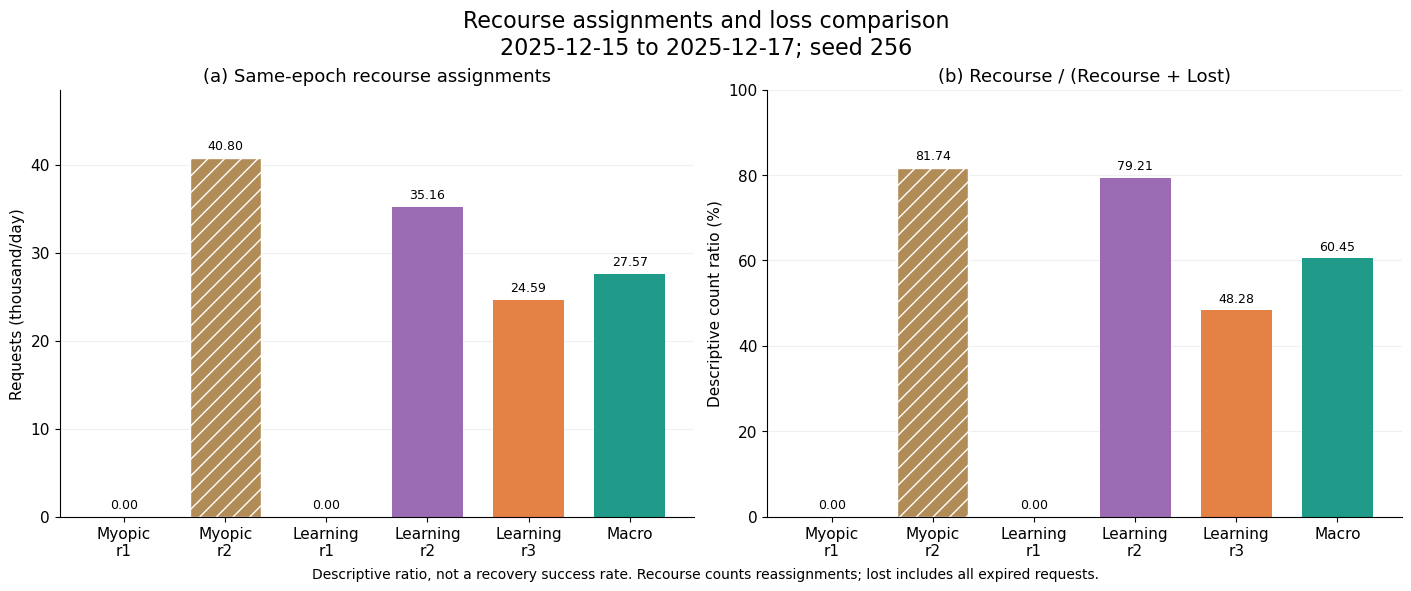

In [5]:
recourse_data = pd.DataFrame(index=ORDER)
recourse_data.index.name = 'Method'
recourse_data['recourse_requests_total'] = raw.recourse_requests
recourse_data['lost_requests_total'] = raw.lost_requests
recourse_data['daily_recourse_assignments'] = raw.recourse_requests / N_DAYS
recourse_data['daily_lost_requests'] = raw.lost_requests / N_DAYS
denominator = recourse_data.recourse_requests_total + recourse_data.lost_requests_total
recourse_data['recourse_over_recourse_plus_lost_pct'] = 100 * recourse_data.recourse_requests_total / denominator.replace(0, np.nan)
np.testing.assert_allclose(
    recourse_data.recourse_over_recourse_plus_lost_pct,
    100 * recourse_data.daily_recourse_assignments / (recourse_data.daily_recourse_assignments + recourse_data.daily_lost_requests),
    equal_nan=True,
)
display(recourse_data.round(2))
recourse_data.to_csv(ANALYSIS_DIR / 'recourse_comparison.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), layout='constrained')
bars(axes[0], recourse_data.daily_recourse_assignments / 1000,
     '(a) Same-epoch recourse assignments', 'Requests (thousand/day)', '.2f')
bars(axes[1], recourse_data.recourse_over_recourse_plus_lost_pct,
     '(b) Recourse / (Recourse + Lost)', 'Descriptive count ratio (%)', '.2f')
axes[1].set_ylim(0, 100)
fig.suptitle('Recourse assignments and loss comparison\n' + PERIOD, fontsize=16)
fig.supxlabel('Descriptive ratio, not a recovery success rate. Recourse counts reassignments; lost includes all expired requests.', fontsize=10)
save_show(fig, '02_recourse_comparison', 'Six methods: daily same-epoch recourse assignments and recourse/(recourse+lost), a descriptive count ratio')


## 保存与验证

图像保留图中数值；CSV 保留未四舍五入的数据。检查所有原始 Excel 的 SHA-256，确保来源未被改动。

In [6]:
assert len(FIGURES) == 2
for source in source_info:
    assert hashlib.sha256((DATA_DIR / source['file']).read_bytes()).hexdigest() == source['sha256'], '原始工作簿发生变化'
manifest = {'seed': SEED, 'days': N_DAYS, 'dates': [pd.Timestamp(d).strftime('%Y-%m-%d') for d in DATES],
            'epoch_seconds': EPOCH_SECONDS, 'uncertainty': 'No confidence intervals: one seed per method',
            'sources': source_info, 'figures': FIGURES}
(ANALYSIS_DIR / 'paper_figures_manifest.json').write_text(json.dumps(manifest, indent=2, ensure_ascii=False))
print(f'{len(FIGURES)} figures saved as PNG + PDF to {FIG_DIR}')
display(pd.DataFrame(FIGURES))

2 figures saved as PNG + PDF to /Users/seinzhou/Desktop/icaps/results/nye_results/paper_figures


,name,description
0,01_policy_overview,"Daily reward/completions, pooled service rate,..."
1,02_recourse_comparison,Six methods: daily same-epoch recourse assignm...
